# **Financial Serive Costomer Complaint Analysis**

In [ ]:
import numpy as np
import pandas as pd

df=pd.read_csv('/content/drive/MyDrive/Data set/complaints data.csv')
df.head(2)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,03/30/2024,Vehicle loan or lease,Loan,Problems at the end of the loan or lease,Unable to receive car title or other problem a...,I requested an extension on past due payments ...,Company has responded to the consumer and the ...,FC HoldCo LLC,NJ,8820,NaN,Consent provided,Web,03/30/2024,Closed with explanation,Yes,NaN,8661797.0
1,03/11/2024,Debt collection,I do not know,Attempts to collect debt not owed,Debt is not yours,This serves as an effort to rectify inaccurate...,NaN,"EQUIFAX, INC.",IL,60153,NaN,Consent provided,Web,03/11/2024,Closed with non-monetary relief,Yes,NaN,8525142.0


In [ ]:
list(df.columns)

['Date received',
 'Product',
 'Sub-product',
 'Issue',
 'Sub-issue',
 'Consumer complaint narrative',
 'Company public response',
 'Company',
 'State',
 'ZIP code',
 'Tags',
 'Consumer consent provided?',
 'Submitted via',
 'Date sent to company',
 'Company response to consumer',
 'Timely response?',
 'Consumer disputed?',
 'Complaint ID']

In [ ]:
df.nunique()

Date received                     172
Product                            12
Sub-product                        55
Issue                              86
Sub-issue                         203
Consumer complaint narrative    58226
Company public response            10
Company                          1425
State                              58
ZIP code                         6242
Tags                                4
Consumer consent provided?          2
Submitted via                       2
Date sent to company               94
Company response to consumer        6
Timely response?                    2
Consumer disputed?                  0
Complaint ID                    85661
dtype: int64

In [ ]:
df.Product.unique()

array(['Vehicle loan or lease', 'Debt collection',
       'Credit reporting or other personal consumer reports', 'Mortgage',
       nan, 'Credit card',
       'Money transfer, virtual currency, or money service',
       'Checking or savings account', 'Student loan',
       'Payday loan, title loan, personal loan, or advance loan',
       'Debt or credit management', 'Prepaid card', ' or'], dtype=object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94679 entries, 0 to 94678
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date received                 89947 non-null  object 
 1   Product                       89940 non-null  object 
 2   Sub-product                   89955 non-null  object 
 3   Issue                         89962 non-null  object 
 4   Sub-issue                     87435 non-null  object 
 5   Consumer complaint narrative  89927 non-null  object 
 6   Company public response       57040 non-null  object 
 7   Company                       89934 non-null  object 
 8   State                         89453 non-null  object 
 9   ZIP code                      89916 non-null  object 
 10  Tags                          7729 non-null   object 
 11  Consumer consent provided?    89943 non-null  object 
 12  Submitted via                 89951 non-null  object 
 13  D

In [ ]:
df.isna().sum()

Date received                    4732
Product                          4739
Sub-product                      4724
Issue                            4717
Sub-issue                        7244
Consumer complaint narrative     4752
Company public response         37639
Company                          4745
State                            5226
ZIP code                         4763
Tags                            86950
Consumer consent provided?       4736
Submitted via                    4728
Date sent to company             4743
Company response to consumer     4749
Timely response?                 4744
Consumer disputed?              94679
Complaint ID                     4718
dtype: int64

# **Exploratory Data Analysis (EDA)**

In [ ]:
subissue_to_issue = df.dropna(subset=['Issue']).drop_duplicates('Sub-issue').set_index('Sub-issue')['Issue'].to_dict()

def fill_Issue(row):
    if pd.isna(row['Issue']):
        return subissue_to_issue.get(row['Sub-issue'], np.nan)
    return row['Issue']

df['Issue'] = df.apply(fill_Issue, axis=1)

In [ ]:
issue_to_subproduct = df.dropna(subset=['Sub-product']).drop_duplicates('Issue').set_index('Issue')['Sub-product'].to_dict()

def fill_Sub_product(row):
    if pd.isna(row['Sub-product']):
        return issue_to_subproduct.get(row['Issue'], np.nan)
    return row['Sub-product']

df['Sub-product'] = df.apply(fill_Sub_product, axis=1)


In [ ]:
subproduct_to_product = df.dropna(subset=['Product']).drop_duplicates('Sub-product').set_index('Sub-product')['Product'].to_dict()

def fill_product(row):
    if pd.isna(row['Product']):
        return subproduct_to_product.get(row['Sub-product'], np.nan)
    return row['Product']

df['Product'] = df.apply(fill_product, axis=1)
df.isna().sum()

Date received                    4732
Product                             0
Sub-product                         0
Issue                               1
Sub-issue                        7244
Consumer complaint narrative     4752
Company public response         37639
Company                          4745
State                            5226
ZIP code                         4763
Tags                            86950
Consumer consent provided?       4736
Submitted via                    4728
Date sent to company             4743
Company response to consumer     4749
Timely response?                 4744
Consumer disputed?              94679
Complaint ID                     4718
dtype: int64

In [ ]:
df['Date received']=pd.to_datetime(df['Date received'],format='mixed',errors='coerce')
df['Date received']=df['Date received'].dt.strftime('%d/%m/%Y')
df['Date sent to company']=pd.to_datetime(df['Date sent to company'],format='mixed')
df['Date sent to company']=df['Date sent to company'].dt.strftime('%d/%m/%Y')
df[['Date received','Date sent to company']]

,Date received,Date sent to company
0,30/03/2024,30/03/2024
1,11/03/2024,11/03/2024
2,02/03/2024,02/03/2024
3,11/03/2024,11/03/2024
4,08/03/2024,08/03/2024
...,...,...
94674,13/03/2024,NaN
94675,08/02/2024,08/02/2024
94676,06/03/2024,06/03/2024
94677,12/02/2024,12/02/2024


In [ ]:
#This step fills the null values of each other as both dates columns are same
df['Date received'] = df['Date received'].combine_first(df['Date sent to company'])
df['Date sent to company'] = df['Date sent to company'].combine_first(df['Date received'])

In [ ]:
#Eplace the invalid values in zip column with 'invalid zip'
def validate_zipcode(z):
  if isinstance (z, str) and len(str(z)) == 5 and z.isdigit():
    return z
  else:
    return 'invalid ZIP'

df['ZIP code']=df['ZIP code'].apply(validate_zipcode)
df['ZIP code']

0        invalid ZIP
1              60153
2        invalid ZIP
3              29483
4              61820
            ...     
94674          55901
94675    invalid ZIP
94676          30045
94677    invalid ZIP
94678          79761
Name: ZIP code, Length: 94679, dtype: object

In [ ]:
df['Consumer complaint narrative']=df['Consumer complaint narrative'].fillna('N/A')

In [ ]:
df['Sub-issue'].replace(np.nan,'None',inplace=True)
df['Company public response'].replace(np.nan,'None',inplace=True)
df['State'].replace(np.nan,'None',inplace=True)
df['Tags'].replace(np.nan,'None',inplace=True)
df['Consumer consent provided?'].replace([np.nan,'N/A'],'None',inplace=True)
df['Submitted via'].replace(np.nan,'No info',inplace=True)
df['Company response to consumer'].replace(np.nan,'No info',inplace=True)
df['Timely response?'].replace(np.nan,'No info',inplace=True)
df['Company'].replace(np.nan,'N/A',inplace=True)
df.dropna(subset=['Date received'],inplace=True)
df.drop(df[df['Product'] == 'or'].index,inplace=True)
df.drop(df[df['Company public response'] == '600XX'].index,inplace=True)

In [ ]:
df.isna().sum()

Date received                     203
Product                             0
Sub-product                         0
Issue                               1
Sub-issue                        7244
Consumer complaint narrative        0
Company public response         37639
Company                          4745
State                            5226
ZIP code                            0
Tags                            86950
Consumer consent provided?       4736
Submitted via                    4728
Date sent to company              203
Company response to consumer     4749
Timely response?                 4744
Consumer disputed?              94679
Complaint ID                     4718
dtype: int64

In [ ]:
#Calculate Complaints by top 5 Product
Product_list = df.groupby(['Product']).size().reset_index(name='Complaint by Product').sort_values('Complaint by Product',ascending=False)
Product_list['Complaint by Product (%)']=((Product_list['Complaint by Product']/Product_list['Complaint by Product'].sum())*100).round(2)
Product_list.head(5)

,Product,Complaint by Product,Complaint by Product (%)
3,Credit reporting or other personal consumer re...,66884,70.64
4,Debt collection,9545,10.08
2,Credit card,6012,6.35
1,Checking or savings account,4525,4.78
7,Mortgage,2290,2.42


In [ ]:
#Identify rows where 'Complaint by Product (%)' is less than 2.42%
mask = Product_list['Complaint by Product (%)'] < 2.42

#Aggregate the values
Other_row = Product_list[mask].sum()
Other_row['Product'] = 'Others'
Other_df = pd.DataFrame([Other_row])

#Remove the rows where 'Complaint by Product (%)' is less than 2.42%
Product_list_without_others=Product_list[~mask]

#Concat both DataFrame
Product_list_with_others=pd.concat([Product_list_without_others,Other_df],ignore_index=True)
Product_list_with_others

,Product,Complaint by Product,Complaint by Product (%)
0,Credit reporting or other personal consumer re...,66884,70.64
1,Debt collection,9545,10.08
2,Credit card,6012,6.35
3,Checking or savings account,4525,4.78
4,Mortgage,2290,2.42
5,Others,5423,5.72


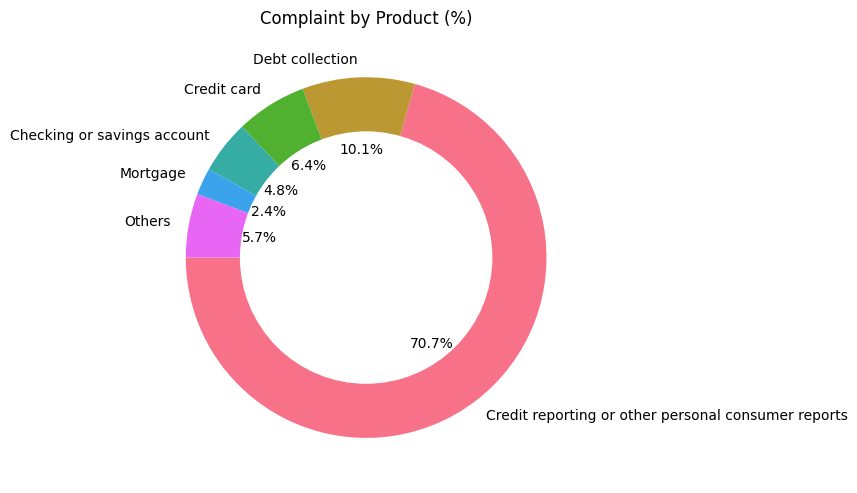

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the color palette
colors = sns.color_palette('pastel')[0:len(Product_list_with_others)]

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(Product_list_with_others['Complaint by Product (%)'], labels=Product_list_with_others['Product'], autopct='%1.1f%%', startangle=180, colors=sns.color_palette("husl"))
plt.gca().add_artist(plt.Circle((0,0),0.70,fc='white')) # Draw a circle to make it a donut chart
plt.title('Complaint by Product (%)')
plt.tight_layout()
plt.show()


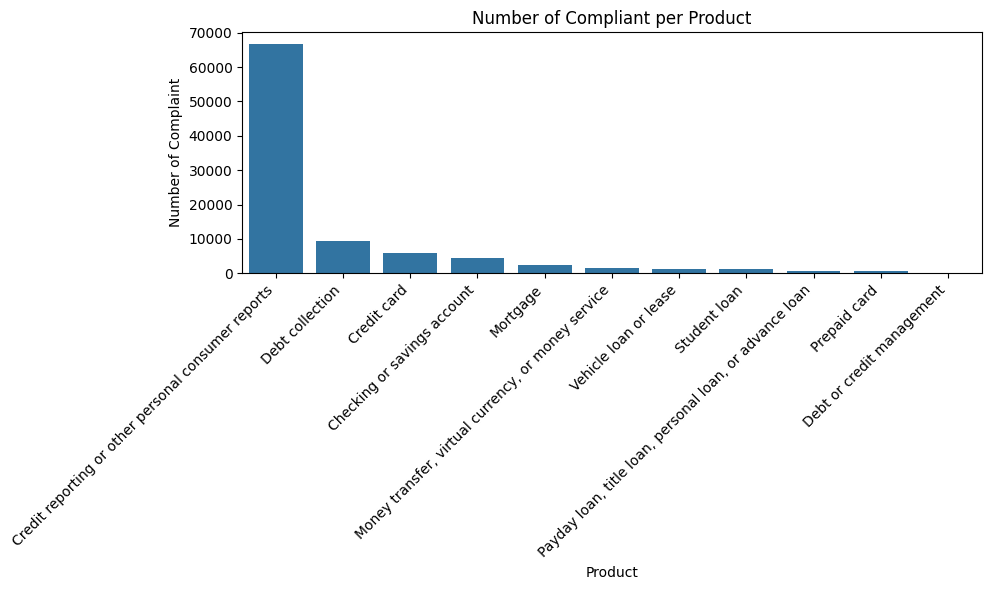

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

product_issues=df['Product'].value_counts().reset_index()
product_issues.columns=['Product','Number of Issues']
plt.figure(figsize=(10, 6))
sns.barplot(x='Product',y='Number of Issues',data=product_issues)
plt.xlabel('Product')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Complaint')
plt.title('Number of Compliant per Product')
plt.tight_layout()
plt.show()


In [ ]:
#Calculate Complaints by top 5 Sub-Product

Sub_product_list = df.groupby(['Sub-product']).size().reset_index(name='Compliant by Sub-product').sort_values('Compliant by Sub-product',ascending=False)
Sub_product_list['Compliant by Sub-Issues (%)']=((Sub_product_list['Compliant by Sub-product']/Sub_product_list['Compliant by Sub-product'].sum())*100).round(2)
Sub_product_list.head(5)

,Sub-product,Compliant by Sub-product,Compliant by Sub-Issues (%)
7,Credit reporting,66326,70.20
15,General-purpose credit card or charge card,5013,5.31
3,Checking account,3662,3.88
20,I do not know,3027,3.20
33,Other debt,1933,2.05


In [ ]:
#Identify rows where 'Compliant by Issues (%)' is less than 2.05%
mask = Sub_product_list['Compliant by Sub-Issues (%)'] < 2.05

#Aggregate the values
Other_row = Sub_product_list[mask].sum()
Other_row['Sub-product'] = 'Others'
Other_df = pd.DataFrame([Other_row])

#Remove the rows where 'Complaint by Product (%)' is less than 2.42%
Sub_Product_list_without_others=Sub_product_list[~mask]

#Concat both DataFrame
Sub_Product_list_with_others=pd.concat([Sub_Product_list_without_others,Other_df],ignore_index=True)
Sub_Product_list_with_others

,Sub-product,Compliant by Sub-product,Compliant by Sub-Issues (%)
0,Credit reporting,66326,70.20
1,General-purpose credit card or charge card,5013,5.31
2,Checking account,3662,3.88
3,I do not know,3027,3.20
4,Other debt,1933,2.05
5,Others,14515,15.37


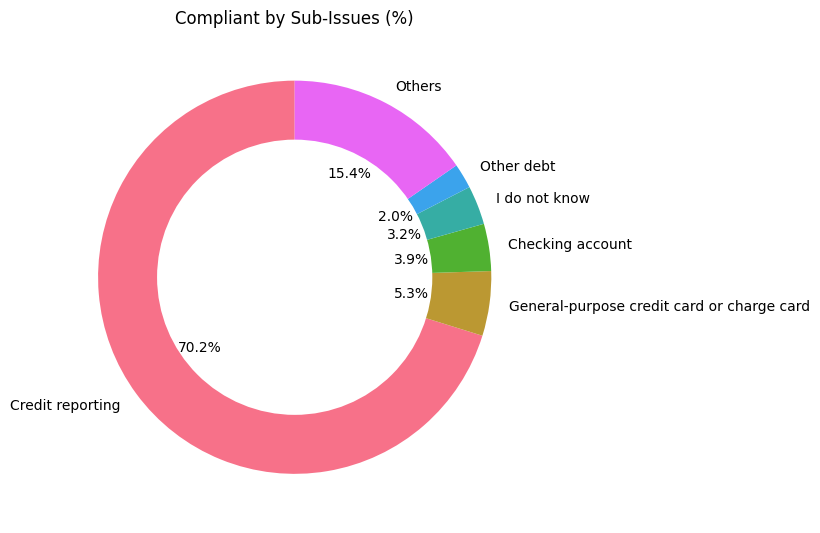

In [ ]:
# Set the color palette
colors = sns.color_palette('pastel')[0:len(Sub_Product_list_with_others)]

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(Sub_Product_list_with_others['Compliant by Sub-Issues (%)'], labels=Sub_Product_list_with_others['Sub-product'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette("husl"))
plt.gca().add_artist(plt.Circle((0,0),0.70,fc='white')) # Draw a circle to make it a donut chart
plt.title('Compliant by Sub-Issues (%)')
plt.tight_layout()
plt.show()

In [ ]:
#Calculate Complaints by top 5 Issues

Issue_list = df.groupby(['Issue']).size().reset_index(name='Compliant by Issues').sort_values('Compliant by Issues',ascending=False)
Issue_list['Compliant by Issues (%)']=((Issue_list['Compliant by Issues']/Issue_list['Compliant by Issues'].sum())*100).round(2)
Issue_list.head(5)

,Issue,Compliant by Issues,Compliant by Issues (%)
30,Incorrect information on your report,30143,31.91
28,Improper use of your report,20027,21.20
51,Problem with a company's investigation into an...,16872,17.86
3,Attempts to collect debt not owed,4160,4.40
84,Written notification about debt,3320,3.51


In [ ]:
#Identify rows where 'Compliant by Issues (%)' is less than 3.51%
mask = Issue_list['Compliant by Issues (%)'] < 3.51

#Aggregate the values
Other_row = Issue_list[mask].sum()
Other_row['Issue'] = 'Others'
Other_df = pd.DataFrame([Other_row])

#Remove the rows where 'Complaint by Product (%)' is less than 2.42%
Issue_list_without_others=Issue_list[~mask]

#Concat both DataFrame
Issue_list_with_others=pd.concat([Issue_list_without_others,Other_df],ignore_index=True)
Issue_list_with_others

,Issue,Compliant by Issues,Compliant by Issues (%)
0,Incorrect information on your report,30143,31.91
1,Improper use of your report,20027,21.20
2,Problem with a company's investigation into an...,16872,17.86
3,Attempts to collect debt not owed,4160,4.40
4,Written notification about debt,3320,3.51
5,Others,19954,21.14


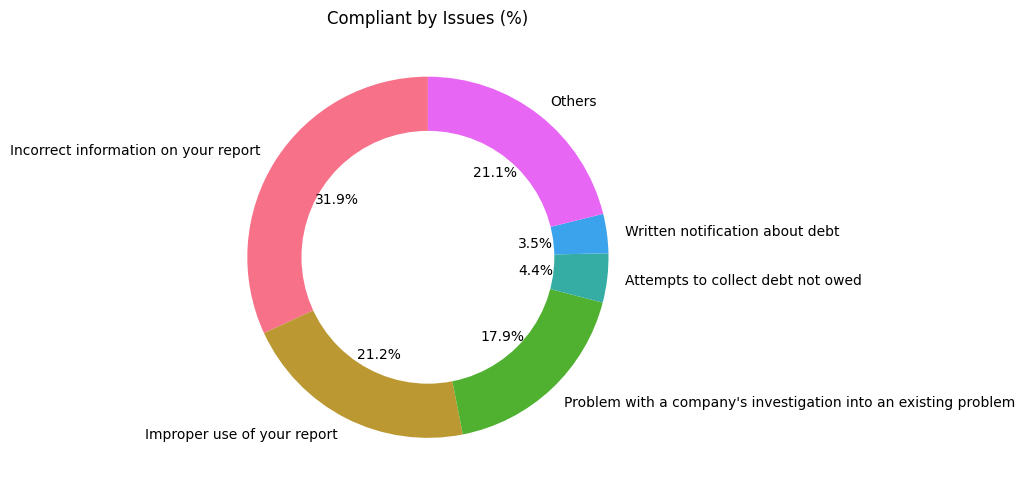

In [ ]:
# Set the color palette
colors = sns.color_palette('pastel')[0:len(Issue_list_with_others)]

# Create a pie chart
plt.figure(figsize=(9, 8))
plt.pie(Issue_list_with_others['Compliant by Issues (%)'], labels=Issue_list_with_others['Issue'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette("husl"))
plt.gca().add_artist(plt.Circle((0,0),0.70,fc='white')) # Draw a circle to make it a donut chart
plt.title('Compliant by Issues (%)')
plt.tight_layout()
plt.show()

In [ ]:
#Calculate Complaints by top 5 Sub-Issues

Sub_Issue_list = df.groupby(['Sub-issue']).size().reset_index(name='Compliant by Sub_Issues').sort_values('Compliant by Sub_Issues',ascending=False)
Sub_Issue_list['Compliant by Sub_Issues (%)']=((Sub_Issue_list['Compliant by Sub_Issues']/Sub_Issue_list['Compliant by Sub_Issues'].sum())*100).round(2)
Sub_Issue_list.head(10)

,Sub-issue,Compliant by Sub_Issues,Compliant by Sub_Issues (%)
93,Information belongs to someone else,16632,17.60
168,Reporting company used your report improperly,14343,15.18
176,Their investigation did not fix an error on yo...,8661,9.17
113,None,7226,7.65
53,Credit inquiries on your report that you don't...,4559,4.83
0,Account information incorrect,4423,4.68
4,Account status incorrect,4353,4.61
98,Investigation took more than 30 days,3284,3.48
200,Was not notified of investigation status or re...,3243,3.43
56,Debt is not yours,2171,2.30


In [ ]:
#Identify rows where 'Compliant by Issues (%)' is less than 2.30%
mask = Sub_Issue_list['Compliant by Sub_Issues (%)'] < 2.30

#Aggregate the values
Other_row = Sub_Issue_list[mask].sum()
Other_row['Sub-issue'] = 'Others'
Other_df = pd.DataFrame([Other_row])

#Remove the rows where 'Complaint by Product (%)' is less than 2.30%
Sub_Issue_list_without_others=Sub_Issue_list[~mask]

#Concat both DataFrame
Sub_Issue_list_with_others=pd.concat([Sub_Issue_list_without_others,Other_df],ignore_index=True)
Sub_Issue_list_with_others

,Sub-issue,Compliant by Sub_Issues,Compliant by Sub_Issues (%)
0,Information belongs to someone else,16632,17.60
1,Reporting company used your report improperly,14343,15.18
2,Their investigation did not fix an error on yo...,8661,9.17
3,None,7226,7.65
4,Credit inquiries on your report that you don't...,4559,4.83
5,Account information incorrect,4423,4.68
6,Account status incorrect,4353,4.61
7,Investigation took more than 30 days,3284,3.48
8,Was not notified of investigation status or re...,3243,3.43
9,Debt is not yours,2171,2.30


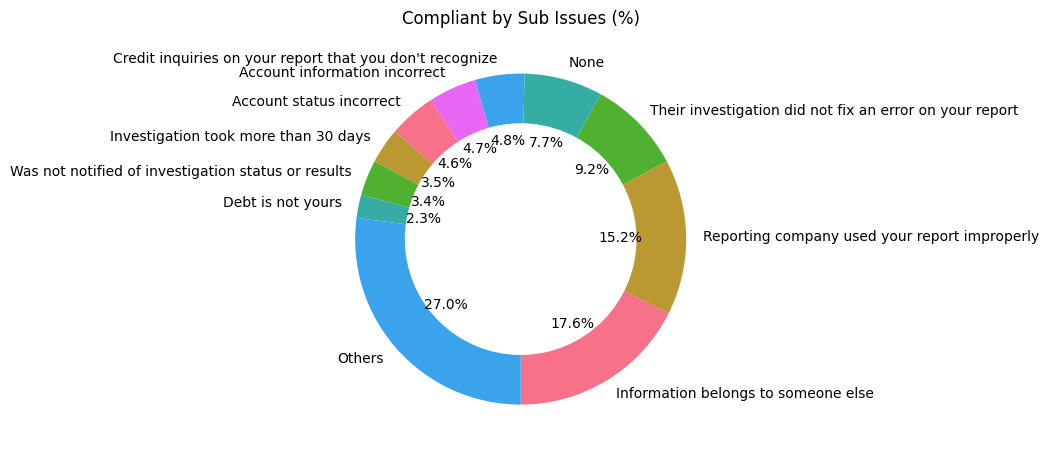

In [ ]:
# Set the color palette
colors = sns.color_palette('pastel')[0:len(Sub_Issue_list_with_others)]

# Create a pie chart
plt.figure(figsize=(10,10))
plt.pie(Sub_Issue_list_with_others['Compliant by Sub_Issues (%)'], labels=Sub_Issue_list_with_others['Sub-issue'], autopct='%1.1f%%', startangle=270, colors=sns.color_palette("husl"))
plt.gca().add_artist(plt.Circle((0,0),0.70,fc='white')) # Draw a circle to make it a donut chart
plt.title('Compliant by Sub Issues (%)')
plt.tight_layout()
plt.show()

In [ ]:
#Calculate the compaint volume by Company name
company_complaint=df.groupby('Company').size().reset_index(name='Complaint count')
company_complaint['Complaint count(%)']=((company_complaint['Complaint count']/company_complaint['Complaint count'].sum())*100).round(2)
company_complaint.sort_values('Complaint count(%)',ascending=False,inplace=True)
company_complaint.head(10)

,Company,Complaint count,Complaint count(%)
1251,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",27546,29.16
492,Experian Information Solutions Inc.,16657,17.63
467,"EQUIFAX, INC.",16541,17.51
885,N/A,4736,5.01
1377,WELLS FARGO & COMPANY,1631,1.73
264,"CITIBANK, N.A.",1579,1.67
169,"BANK OF AMERICA, NATIONAL ASSOCIATION",1306,1.38
240,CAPITAL ONE FINANCIAL CORPORATION,1120,1.19
698,JPMORGAN CHASE & CO.,1113,1.18
1152,SYNCHRONY FINANCIAL,953,1.01


In [ ]:
company_response=df.groupby(['Company','Company public response']).size().reset_index(name='Complaint count')
company_response

,Company,Company public response,Complaint count
0,"1803 Capital, LLC",None,1
1,"1ST RESULTS BILLINGS & COLLECTIONS, INC.",None,1
2,1st Franklin Financial Corporation,None,5
3,21ST MORTGAGE CORP.,None,6
4,2233 Paradise Road LLC,None,2
...,...,...,...
1766,ZuntaFi Corp,Company believes it acted appropriately as aut...,1
1767,ZuntaFi Corp,Company has responded to the consumer and the ...,2
1768,ZuntaFi Corp,None,1
1769,"eMoneyUSA Holdings, LLC",None,1


In [ ]:
company_response['total complaint of company']=company_response.groupby('Company')['Complaint count'].transform('sum')
company_response

,Company,Company public response,Complaint count,total complaint of company
0,"1803 Capital, LLC",None,1,1
1,"1ST RESULTS BILLINGS & COLLECTIONS, INC.",None,1,1
2,1st Franklin Financial Corporation,None,5,5
3,21ST MORTGAGE CORP.,None,6,6
4,2233 Paradise Road LLC,None,2,2
...,...,...,...,...
1766,ZuntaFi Corp,Company believes it acted appropriately as aut...,1,4
1767,ZuntaFi Corp,Company has responded to the consumer and the ...,2,4
1768,ZuntaFi Corp,None,1,4
1769,"eMoneyUSA Holdings, LLC",None,1,1


In [ ]:
company_response['Rank by total complaint']=company_response['total complaint of company'].rank(method='dense', ascending=False)
company_response.sort_values('Rank by total complaint',ascending=True,inplace=True)
company_response.head(5)

,Company,Company public response,Complaint count,total complaint of company,Rank by total complaint
1550,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",Company has responded to the consumer and the ...,25606,27546,1.0
1551,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",None,1940,27546,1.0
594,Experian Information Solutions Inc.,Company has responded to the consumer and the ...,14602,16657,2.0
595,Experian Information Solutions Inc.,None,2053,16657,2.0
593,Experian Information Solutions Inc.,Company believes it acted appropriately as aut...,2,16657,2.0


In [ ]:
top_7_rank_total_complaints=company_response[company_response['Rank by total complaint']<=7]
top_7_rank_total_complaints

,Company,Company public response,Complaint count,total complaint of company,Rank by total complaint
1550,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",Company has responded to the consumer and the ...,25606,27546,1.0
1551,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",None,1940,27546,1.0
594,Experian Information Solutions Inc.,Company has responded to the consumer and the ...,14602,16657,2.0
595,Experian Information Solutions Inc.,None,2053,16657,2.0
593,Experian Information Solutions Inc.,Company believes it acted appropriately as aut...,2,16657,2.0
564,"EQUIFAX, INC.",None,16541,16541,3.0
1082,N/A,Company believes complaint represents an oppor...,5,4736,4.0
1085,N/A,Company believes the complaint provided an opp...,6,4736,4.0
1084,N/A,Company believes the complaint is the result o...,5,4736,4.0
1089,N/A,None,1851,4736,4.0


These are top 7 companies which have highest number of complaints. Their complaints distribution and company public resposnse also presented in 'top_7_rank_total_complaints' dataframe.



1.   All companies have responded to CFPB and customer But they are not willing to provide public response.
2.   Company 'TRANSUNION INTERMEDIATE HOLDINGS, INC.' accounts for 29.15% complaints which is top rank company in pespective of number of complaints. company 'Experian Information Solutions Inc.' and 'EQUIFAX, INC.' holds 2nd and 3rd rank with 17.63% and 17.50% complaints respectively.

1.   70.64% issues were reported for product 'Credit reporting or other personal consumer reports' where 10.07% for Debt collection and 6.35 % for credit card
2.   70.20% issues were reported for Sub-product 'Credit reporting',  5.30% for 'General-purpose credit card or charge card' and 3.80% for 'Checking account'.







